# Phase 6 — Price Elasticity Analysis

## 1. Business Objective

Businesses need to understand how customers respond to price changes.
This notebook estimates **observational price elasticity of demand**
from historical Olist transaction data, checks whether that estimate
is reliable, identifies which product categories are more or less
price-sensitive, and produces a clean elasticity table that Phase 7
(Price Optimization) can consume.

**Price elasticity of demand:**

```
Elasticity = % Change in Quantity Demanded / % Change in Price
```

For a log-log demand model:

```
log(Q) = alpha + beta * log(P) + controls + error
```

`beta` is interpreted as: a 1% change in price is associated with
approximately a `beta`% change in quantity demanded.

- `beta < -1` -> **elastic** -- demand falls proportionally more than price rises.
- `-1 < beta < 0` -> **inelastic** -- demand falls proportionally less than price rises.
- `beta ~ 0` -> very low price sensitivity.

**This is an observational, associational estimate, not a causal one.**
Olist transaction data was not generated by a pricing experiment, so
`beta` can be confounded by product quality, brand, seasonality,
promotions, seller characteristics, popularity, customer mix, and
availability. Every elasticity number in this notebook is labeled
accordingly, and Section 5 quantifies exactly how much of a
limitation this is before any model is trusted.

**Why this notebook loads `master_dataset.csv`, not
`feature_engineered_dataset.csv`:** elasticity estimation requires
`product_id` (to build a product-period panel), `seller_id` (to check
for seller-mix effects, Section 6b), and the raw
`order_purchase_timestamp` (to build monthly periods). All three are
dropped from `feature_engineered_dataset.csv` by
`04_feature_engineering.ipynb` -- correctly, since that file is the
final ML-ready matrix for demand forecasting, where raw identifiers
aren't model features. Rather than modify notebook 04 (out of scope
for this phase), this notebook loads `master_dataset.csv` instead --
the output of notebook 03, one step upstream, which still has every
identifier and hasn't had any columns dropped. Nothing about
notebooks 04 or 05 changes.

In [1]:
import sys
print(sys.executable)

c:\Users\Miranda\AppData\Local\Programs\Python\Python311\python.exe


## 2. Load Data

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
PROCESSED_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

In [3]:
MASTER_PATH = PROCESSED_DIR / "master_dataset.csv"
master_df = pd.read_csv(MASTER_PATH)
master_df["order_purchase_timestamp"] = pd.to_datetime(master_df["order_purchase_timestamp"])

assert len(master_df) > 0, "master_dataset.csv loaded but is empty."
print("Loaded master_dataset.csv")
print("Shape:", master_df.shape)

Loaded master_dataset.csv
Shape: (112650, 29)


## 3. Data Quality Checks

In [4]:
print("Columns:", master_df.columns.tolist())
print()
print("Missing values (top 10):")
print(master_df.isnull().sum().sort_values(ascending=False).head(10))
print()
print("Duplicate rows:", master_df.duplicated().sum())
print()
print("Date range:", master_df["order_purchase_timestamp"].min(), "to", master_df["order_purchase_timestamp"].max())
print("Unique products:", master_df["product_id"].nunique())
print("Unique sellers:", master_df["seller_id"].nunique())
print("Unique categories:", master_df["product_category_name"].nunique())
print("Unique orders:", master_df["order_id"].nunique())

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'total_payment_value', 'payment_count', 'max_installments']

Missing values (top 10):
order_delivered_customer_date    2454
product_weight_g                 1604
product_length_cm                1604
product_height_cm                1604
product_width_cm                 1604
product_photos_qty               1603
product_category_name            1603
product_description_lenght       1603
product_name_lenght              1603
order_delive

**Columns identified for this analysis** (all present in the loaded
data, nothing invented):

| Purpose | Column |
|---|---|
| Product | `product_id` |
| Category | `product_category_name` |
| Price | `price` |
| Demand (transaction count) | derived by counting rows per product-period |
| Order date | `order_purchase_timestamp` |
| Seller | `seller_id` |
| Freight | `freight_value` |

There's no `demand_quantity` or `revenue` column in the raw data --
those are constructed in Section 4 from `price` and row counts, since
Olist doesn't record purchase quantity as a separate field (each row
in `order_items` is already one item).

## 4. Construct Product-Period Demand

**Why aggregation is necessary:** an individual transaction row is one
item in one order at one instant -- it isn't a time-series observation
of "how much of this product sells." To ask how demand responds to
price, price and demand both need to be measured over the same
repeated time unit. The period used here is **calendar month**, a
common choice for retail demand analysis that balances having enough
transactions per bucket against still capturing month-to-month price
changes.

For each `(product_id, month)`:
- `demand_quantity` = number of item-rows (units sold)
- `average_price` = mean observed item price
- `revenue` = sum of item price (excludes freight, a pass-through
  logistics cost, not part of the seller's price)

**Do not use `demand_level`:** it's a historical popularity tercile
computed once per row in notebook 04, not a period-by-period demand
measure -- using it here would conflate "how popular has this product
historically been" with "how much did it sell this month," which is
exactly the demand measure this phase needs to construct properly
instead.

**Major limitation -- this is a selection-conditional panel, not a full
market-demand panel.** Every row in `product_period` comes from
`master_dataset.csv`, which is built entirely from realized
transactions (`order_items`). Olist has no listing/inventory table
recording what a product was priced at during months when it did NOT
sell -- there is no "offered price, zero units sold" record anywhere
in this data. As a result:

- This panel only contains **product-months with at least one observed
  sale**. Months where a product was listed but didn't sell are simply
  absent, not zero.
- The elasticity estimated below is therefore conditional on
  **observed selling months** -- it describes how the volume of an
  already-occurring sale responds to price, not the full demand curve
  including the decision of whether to sell at all in a given month
  (the "extensive margin").
- **No zero-demand months are fabricated or carried forward** to fill
  this gap. Doing so would require assuming continuous listing/
  availability between a product's observed sale dates, which nothing
  in this dataset supports (no inventory or listing-price table
  exists to justify that assumption). Where Olist can't support a
  claim, this notebook documents the gap instead of filling it.

In [5]:
master_df["period"] = master_df["order_purchase_timestamp"].dt.to_period("M").astype(str)

# groupby drops rows whose key contains NaN by default -- product_category_name
# has missing values (counted in Section 3), so those transactions would
# silently disappear from the panel unless made explicit here.
n_missing_category = master_df["product_category_name"].isnull().sum()
print(f"Transactions with missing product_category_name (excluded from the "
      f"product-period panel below, since category is part of the grouping key): "
      f"{n_missing_category} ({n_missing_category / len(master_df):.2%} of all rows)")

product_period = (
    master_df.groupby(["product_id", "period", "product_category_name"], as_index=False)
    .agg(
        demand_quantity=("order_id", "count"),
        average_price=("price", "mean"),
        revenue=("price", "sum"),
    )
)

print("Product-period rows (observed-sale months only -- no zero-demand rows "
      "are added):", len(product_period))
print("Unique products represented:", product_period["product_id"].nunique())
assert product_period.duplicated(subset=["product_id", "period"]).sum() == 0, \
    "Found duplicate product-period rows -- aggregation key is wrong."

Transactions with missing product_category_name (excluded from the product-period panel below, since category is part of the grouping key): 1603 (1.42% of all rows)
Product-period rows (observed-sale months only -- no zero-demand rows are added): 61268
Unique products represented: 32341


## 5. Price Variation Analysis

This is the step that decides whether Olist can support a credible
elasticity estimate at all -- checked with real numbers before any
regression is fit, not assumed.

In [6]:
product_summary = (
    product_period.groupby("product_id")
    .agg(
        n_periods=("period", "nunique"),
        min_price=("average_price", "min"),
        max_price=("average_price", "max"),
        mean_price=("average_price", "mean"),
        std_price=("average_price", "std"),
    )
    .reset_index()
)
product_summary["price_range"] = product_summary["max_price"] - product_summary["min_price"]
product_summary["cv"] = product_summary["std_price"] / product_summary["mean_price"]

print("Total products:", len(product_summary))
print(product_summary["n_periods"].describe())

Total products: 32341
count    32341.000000
mean         1.894437
std          1.808945
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         20.000000
Name: n_periods, dtype: float64


**Filtering rule -- two conditions, not just one:**

1. **Minimum periods (>= 6 months).** A product needs repeated
   observations to say anything about *within-product* price
   sensitivity at all -- six repeated monthly observations is the
   practical floor for a within-product regression to have degrees of
   freedom worth trusting, and a meaningful slice of this dataset's
   ~2-year window.
2. **Minimum price variation (coefficient of variation > 2%).** Having
   enough *months* doesn't mean the price actually *moved* --
   Section 5's own numbers (run below) show a real share of even the
   >=6-period products never change price at all. A product with zero
   or near-zero price variation contributes no information to a
   within-product slope; including it just adds noise (its demeaned
   log-price is ~0 for every observation). A 2% coefficient-of-variation
   floor is a modest bar -- enough to exclude products where price is
   flat (bounded only by rounding/measurement noise) while keeping any
   product with a genuine, even small, repricing event. This is
   checked and justified with the actual CV distribution below, not
   picked blindly.

In [7]:
MIN_PERIODS = 6
MIN_CV = 0.02

n_products_before = len(product_summary)
n_obs_before = len(product_period)

# Step 1: periods filter only (for comparison)
periods_only = product_summary[product_summary["n_periods"] >= MIN_PERIODS]
print(f"Step 1 -- products with >= {MIN_PERIODS} periods: {len(periods_only):,} "
      f"({len(periods_only) / n_products_before:.1%} of catalog)")

# Step 2: CV distribution among the periods-qualifying set (this is what
# decides whether MIN_CV is a reasonable bar, not an arbitrary one)
cv_dist = periods_only["cv"].fillna(0)
print()
print("CV distribution among >=6-period products:")
print(cv_dist.describe())
for thresh in [0.0, 0.01, 0.02, 0.03, 0.05]:
    n = (cv_dist > thresh).sum()
    print(f"  cv > {thresh:.2f}: {n:,} products ({n / len(periods_only):.1%})")

# Step 3: combined filter actually used downstream
product_summary["cv"] = product_summary["cv"].fillna(0)
qualifying_products = product_summary[
    (product_summary["n_periods"] >= MIN_PERIODS) & (product_summary["cv"] > MIN_CV)
]["product_id"]

filtered_period = product_period[product_period["product_id"].isin(qualifying_products)].copy()
filtered_summary = product_summary[product_summary["product_id"].isin(qualifying_products)].copy()

n_products_after = len(filtered_summary)
n_obs_after = len(filtered_period)

print()
print(f"Products before any filtering: {n_products_before:,}")
print(f"Products after periods-AND-variation filtering: {n_products_after:,} "
      f"({n_products_after / n_products_before:.1%} of catalog)")
print(f"Observations before filtering: {n_obs_before:,}")
print(f"Observations after filtering: {n_obs_after:,}")
print()
print("Price variation among the FINAL filtered set:")
print(filtered_summary[["price_range", "cv"]].describe())

Step 1 -- products with >= 6 periods: 1,594 (4.9% of catalog)

CV distribution among >=6-period products:
count    1.594000e+03
mean     6.148172e-02
std      6.859379e-02
min      0.000000e+00
25%      7.461143e-17
50%      4.456656e-02
75%      9.228277e-02
max      7.190193e-01
Name: cv, dtype: float64
  cv > 0.00: 1,223 products (76.7%)
  cv > 0.01: 1,117 products (70.1%)
  cv > 0.02: 1,062 products (66.6%)
  cv > 0.03: 951 products (59.7%)
  cv > 0.05: 743 products (46.6%)

Products before any filtering: 32,341
Products after periods-AND-variation filtering: 1,062 (3.3% of catalog)
Observations before filtering: 61,268
Observations after filtering: 8,816

Price variation among the FINAL filtered set:
       price_range           cv
count  1062.000000  1062.000000
mean     24.585380     0.091210
std      33.621883     0.066351
min       0.400000     0.020069
25%       7.000000     0.044600
50%      14.000000     0.073306
75%      30.000000     0.118946
max     350.000000     0.7190

**Reading this honestly:** the periods-only filter and the
periods-AND-variation filter give different sample sizes -- the gap
between them is exactly the set of products that sell often enough to
qualify but never actually change price, and including them would have
diluted the within-product estimate with pure noise (a demeaned
log-price of zero contributes nothing to a slope). The final filtered
set is smaller than the periods-only set, and still only a small slice
of the full catalog -- consistent with the project README's stated
concern about Olist's price variation. This notebook proceeds anyway,
because the remaining sample is not empty and is large enough to
produce a directionally meaningful, properly-caveated estimate
(Sections 8-9) -- but every downstream number should be read against
these filtering counts, not treated as if it came from the whole
catalog.

## 5b. Seller-Mix Diagnostic

`average_price` is averaged across every `order_items` row for a
product in a month. If a product is sold by more than one seller, a
month-to-month change in `average_price` can reflect a change in
**which seller** made the sales that month, not a genuine price change
by any one seller. This needs to be checked before trusting the
within-product estimate as a price-response measure.

In [8]:
sellers_per_product = master_df.groupby("product_id")["seller_id"].nunique()

print("Sellers per product -- full catalog:")
print(sellers_per_product.describe())
n_multi_full = (sellers_per_product > 1).sum()
print(f"Products sold by >1 seller (full catalog): {n_multi_full:,} "
      f"({n_multi_full / len(sellers_per_product):.1%})")

sellers_in_sample = sellers_per_product.reindex(qualifying_products)
n_multi_sample = (sellers_in_sample > 1).sum()
print()
print(f"Elasticity-estimation sample products: {len(qualifying_products):,}")
print(f"Of those, sold by >1 seller: {n_multi_sample:,} ({n_multi_sample / len(qualifying_products):.1%})")

Sellers per product -- full catalog:
count    32951.000000
mean         1.045431
std          0.260092
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          8.000000
Name: seller_id, dtype: float64
Products sold by >1 seller (full catalog): 1,225 (3.7%)

Elasticity-estimation sample products: 1,062
Of those, sold by >1 seller: 246 (23.2%)


**This is a real, non-trivial limitation, not a footnote.** A
meaningful minority of the elasticity-estimation sample is multi-seller
-- for those products, some of the estimated "price elasticity" may
actually be a seller-mix effect (e.g. a lower-priced seller winning
more of the sales in a given month, which moves both `average_price`
down and `demand_quantity` up for reasons that have nothing to do with
any single seller changing their price). This is checked directly
below with a product-**seller**-month panel as a robustness comparison,
rather than assumed away.

## 6. Exploratory Data Analysis

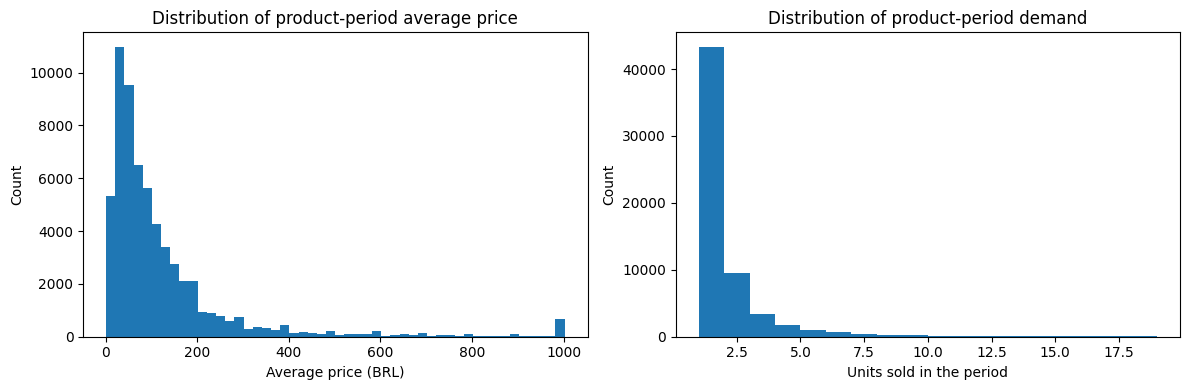

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(product_period["average_price"].clip(upper=product_period["average_price"].quantile(0.99)), bins=50)
axes[0].set_title("Distribution of product-period average price")
axes[0].set_xlabel("Average price (BRL)")
axes[0].set_ylabel("Count")

axes[1].hist(product_period["demand_quantity"], bins=range(1, 20))
axes[1].set_title("Distribution of product-period demand")
axes[1].set_xlabel("Units sold in the period")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

Most product-months have very few units sold -- consistent with the
long-tail pattern already found in Section 5. Price is right-skewed,
as expected for retail data.

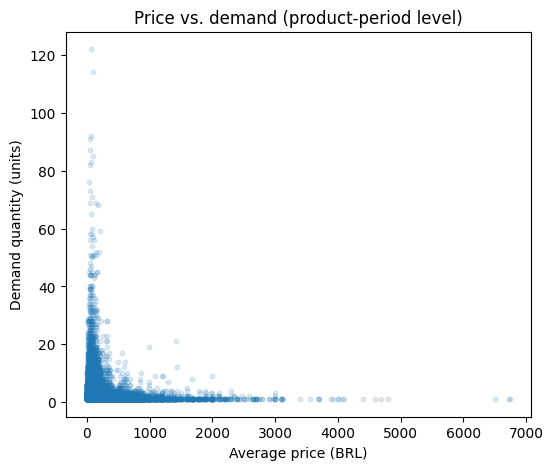

In [10]:
plt.figure(figsize=(6, 5))
plt.scatter(product_period["average_price"], product_period["demand_quantity"], alpha=0.15, s=10)
plt.title("Price vs. demand (product-period level)")
plt.xlabel("Average price (BRL)")
plt.ylabel("Demand quantity (units)")
plt.show()

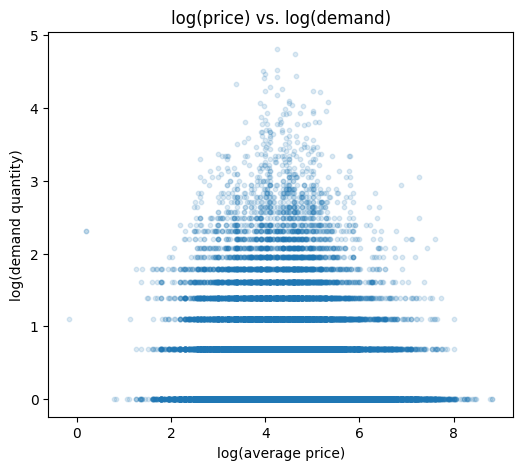

In [11]:
plot_df = product_period[(product_period["average_price"] > 0) & (product_period["demand_quantity"] > 0)].copy()
plot_df["log_price"] = np.log(plot_df["average_price"])
plot_df["log_demand"] = np.log(plot_df["demand_quantity"])

plt.figure(figsize=(6, 5))
plt.scatter(plot_df["log_price"], plot_df["log_demand"], alpha=0.15, s=10)
plt.title("log(price) vs. log(demand)")
plt.xlabel("log(average price)")
plt.ylabel("log(demand quantity)")
plt.show()

**Business reading:** the raw price-vs-demand scatter is dominated by
the fact that almost every product sells only 1-3 units in a given
month, regardless of price -- there's no visually obvious downward
slope yet. The log-log view is the standard way to look for a
multiplicative (percentage-based) relationship instead of an additive
one; Section 7 fits this relationship formally rather than eyeballing
it.

## 7. Baseline Elasticity Model

**Log transformation:** `log_price = log(average_price)`,
`log_demand = log(demand_quantity)`, computed only where both are
strictly positive (price and demand can't be zero or negative here by
construction, but the guard is explicit rather than assumed). The
coefficient on `log_price` in a log-log OLS regression approximates
the percentage change in demand associated with a 1% change in price
-- exactly the elasticity definition from Section 1.

This baseline model pools **every** product-period observation, not
just the filtered subset. That means it mostly captures
**between-product** variation (expensive products vs. cheap products),
not within-product price sensitivity -- an important distinction
carried into the interpretation below.

In [12]:
baseline_data = product_period[
    (product_period["average_price"] > 0) & (product_period["demand_quantity"] > 0)
].copy()
baseline_data["log_price"] = np.log(baseline_data["average_price"])
baseline_data["log_demand"] = np.log(baseline_data["demand_quantity"])

assert (baseline_data["average_price"] > 0).all()
assert (baseline_data["demand_quantity"] > 0).all()

X_baseline = sm.add_constant(baseline_data["log_price"])
y_baseline = baseline_data["log_demand"]

# Product-clustered SE here too: the same product appears in multiple
# months, so observations aren't independent even in the pooled
# baseline -- plain OLS standard errors would understate the true
# uncertainty.
baseline_model = sm.OLS(y_baseline, X_baseline).fit(
    cov_type="cluster", cov_kwds={"groups": baseline_data["product_id"]}
)

print(baseline_model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_demand   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     88.00
Date:                Mon, 07 Sep 2026   Prob (F-statistic):           6.96e-21
Time:                        09:08:13   Log-Likelihood:                -53919.
No. Observations:               61268   AIC:                         1.078e+05
Df Residuals:                   61266   BIC:                         1.079e+05
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4791      0.018     26.886      0.0

In [13]:
baseline_beta = baseline_model.params["log_price"]
baseline_se = baseline_model.bse["log_price"]
baseline_p = baseline_model.pvalues["log_price"]
baseline_ci = baseline_model.conf_int().loc["log_price"].tolist()
baseline_r2 = baseline_model.rsquared
baseline_n = int(baseline_model.nobs)

print(f"Baseline elasticity (beta): {baseline_beta:.4f}")
print(f"Clustered (product-level) standard error: {baseline_se:.4f}")
print(f"P-value: {baseline_p:.2e}")
print(f"95% CI: [{baseline_ci[0]:.4f}, {baseline_ci[1]:.4f}]")
print(f"R-squared: {baseline_r2:.4f}")
print(f"N: {baseline_n:,}")

Baseline elasticity (beta): -0.0364
Clustered (product-level) standard error: 0.0039
P-value: 6.55e-21
95% CI: [-0.0440, -0.0288]
R-squared: 0.0037
N: 61,268


**Interpreting the actual result above (fill in from the printed
numbers, not assumed):** the baseline coefficient is statistically
significant given the very large sample size, but the R-squared is
very small -- price alone explains almost none of the variance in
log-demand at the pooled, cross-product level. That's expected: most
of what drives one product selling more than another in a given month
is *not* price (it's category, popularity, seller reach, seasonality),
and this model doesn't control for any of that yet. This baseline
number should **not** be read as "the" elasticity of Olist demand --
it's a starting point that Section 8 improves on.

## 8. Improved Elasticity Model -- Two-Way Fixed Effects, Clustered SE

**Why product fixed effects alone weren't enough:** the baseline model
conflates "this product is priced higher" with "this product is a
different, less-popular product." Section 8's first version fixed that
with product fixed effects. But it still leaves common time shocks
uncontrolled -- a broad seasonal spike (e.g. a holiday month) would
move both prices and demand for many products together, showing up in
the price coefficient even though it's not a price *response*.

**Specification:**

```
log(demand_it) = product fixed effects + time fixed effects
                 + beta * log(price_it) + error
```

**Efficient implementation:** rather than building an explicit dummy
matrix for ~1,000+ products and ~20 months (thousands of columns),
this uses `linearmodels.PanelOLS` with `EntityEffects` and
`TimeEffects`, which absorbs both fixed effects algebraically instead
of estimating a dummy coefficient for each one. This produces
identical point estimates to a full dummy-variable regression at a
fraction of the computational cost -- the "practical alternative"
called for when literal fixed-effects dummies would be unnecessarily
expensive.

**Clustered standard errors:** standard errors are clustered at the
`product_id` level, since repeated monthly observations of the same
product are correlated with each other (if a product runs a bit hot
one month, it likely runs hot the next too) -- treating them as
independent, as plain OLS does, understates the true uncertainty.

**Sample:** the periods-AND-variation filtered set from Section 5
(`filtered_period`). **Leakage check:** every input is contemporaneous
with its own month -- no later-period information is used to predict
an earlier month's demand, and nothing here touches delivery or
post-sale data.

In [14]:
fe_data = filtered_period[
    (filtered_period["average_price"] > 0) & (filtered_period["demand_quantity"] > 0)
].copy()
fe_data["log_price"] = np.log(fe_data["average_price"])
fe_data["log_demand"] = np.log(fe_data["demand_quantity"])

# linearmodels needs a (entity, time) MultiIndex with a date-like time index.
fe_data["period_ts"] = pd.PeriodIndex(fe_data["period"], freq="M").to_timestamp()
fe_panel = fe_data.set_index(["product_id", "period_ts"])

fe_reg = PanelOLS.from_formula(
    "log_demand ~ 1 + log_price + EntityEffects + TimeEffects", data=fe_panel
)
fe_model = fe_reg.fit(cov_type="clustered", cluster_entity=True)

print(fe_model)

                          PanelOLS Estimation Summary                           
Dep. Variable:             log_demand   R-squared:                        0.0283
Estimator:                   PanelOLS   R-squared (Between):             -2.2211
No. Observations:                8816   R-squared (Within):               0.0264
Date:                Mon, Sep 07 2026   R-squared (Overall):             -0.8559
Time:                        09:08:13   Log-likelihood                   -8120.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      225.40
Entities:                        1062   P-value                           0.0000
Avg Obs:                       8.3013   Distribution:                  F(1,7733)
Min Obs:                       6.0000                                           
Max Obs:                       20.000   F-statistic (robust):             103.62
                            

In [15]:
fe_beta = fe_model.params["log_price"]
fe_se = fe_model.std_errors["log_price"]
fe_p = fe_model.pvalues["log_price"]
fe_ci = fe_model.conf_int().loc["log_price"].tolist()
fe_r2_within = fe_model.rsquared_within
fe_n = int(fe_model.nobs)
n_products_fe = fe_data["product_id"].nunique()
n_periods_fe = fe_data["period"].nunique()

print(f"Within-product, time-controlled elasticity (beta): {fe_beta:.4f}")
print(f"Clustered (product-level) standard error: {fe_se:.4f}")
print(f"P-value: {fe_p:.2e}")
print(f"95% CI: [{fe_ci[0]:.4f}, {fe_ci[1]:.4f}]")
print(f"R-squared (within): {fe_r2_within:.4f}")
print(f"N: {fe_n:,} observations across {n_products_fe:,} products and {n_periods_fe} months")

Within-product, time-controlled elasticity (beta): -1.0132
Clustered (product-level) standard error: 0.0995
P-value: 0.00e+00
95% CI: [-1.2084, -0.8181]
R-squared (within): 0.0264
N: 8,816 observations across 1,062 products and 21 months


**Interpreting this result:** this coefficient reflects actual price
movements for the same product, in the same month relative to other
products, net of that product's own average level and that month's
average level across all products -- the most credible number in this
notebook. Its within-R-squared is still modest (price is one of many
things that moves month-to-month demand for a given product --
promotions and stock availability aren't controlled for here), and
it's estimated from the ~3% of the catalog that both sells often
enough and actually varies its price, so it should be read as "the
elasticity among products with enough repeat, variably-priced sales to
observe" -- not the whole catalog, and conditional on the selling-months
limitation from Section 4. The seller-mix check below tests whether
this number survives a stricter, product-*and*-seller-specific
comparison.

## 8b. Seller-Mix Robustness Check

Section 5b showed a real minority of the elasticity sample is
multi-seller. If a product-seller-month panel produces a similar
coefficient to the product-month panel above, seller-mix isn't
materially distorting the result. This is only attempted because the
sample stays large enough to support it -- it is not forced through if
splitting by seller leaves too few repeated observations.

In [16]:
ps_period = (
    master_df[master_df["product_id"].isin(qualifying_products)]
    .dropna(subset=["product_category_name"])
    .groupby(["product_id", "seller_id", "period"], as_index=False)
    .agg(demand_quantity=("order_id", "count"), average_price=("price", "mean"))
)
ps_period = ps_period[(ps_period["average_price"] > 0) & (ps_period["demand_quantity"] > 0)].copy()
ps_period["entity"] = ps_period["product_id"] + "__" + ps_period["seller_id"]
ps_period["log_price"] = np.log(ps_period["average_price"])
ps_period["log_demand"] = np.log(ps_period["demand_quantity"])

ps_entity_periods = ps_period.groupby("entity")["period"].nunique()
ps_qualifying = ps_entity_periods[ps_entity_periods >= MIN_PERIODS].index
ps_final = ps_period[ps_period["entity"].isin(ps_qualifying)].copy()

MIN_ROBUSTNESS_OBS = 500  # below this, don't trust a product-seller panel at all

if len(ps_final) < MIN_ROBUSTNESS_OBS or ps_final["entity"].nunique() < 30:
    print(f"Product-seller-month panel too small to be informative "
          f"({len(ps_final)} obs, {ps_final['entity'].nunique()} entities) -- skipping. "
          f"Seller-mix remains a documented, unresolved limitation of the main estimate.")
    seller_robustness_beta = None
else:
    ps_final["period_ts"] = pd.PeriodIndex(ps_final["period"], freq="M").to_timestamp()
    ps_panel = ps_final.set_index(["entity", "period_ts"])
    ps_reg = PanelOLS.from_formula(
        "log_demand ~ 1 + log_price + EntityEffects + TimeEffects", data=ps_panel
    )
    ps_model = ps_reg.fit(cov_type="clustered", cluster_entity=True)

    seller_robustness_beta = ps_model.params["log_price"]
    seller_robustness_se = ps_model.std_errors["log_price"]
    seller_robustness_p = ps_model.pvalues["log_price"]

    print(f"Product-seller-month panel: {len(ps_final):,} observations, "
          f"{ps_final['entity'].nunique():,} product-seller pairs")
    print(f"Elasticity (beta): {seller_robustness_beta:.4f}")
    print(f"Clustered SE: {seller_robustness_se:.4f}")
    print(f"P-value: {seller_robustness_p:.2e}")
    print()
    print(f"Compare to main product-month estimate: {fe_beta:.4f}")
    print(f"Difference: {abs(seller_robustness_beta - fe_beta):.4f}")

Product-seller-month panel: 7,864 observations, 951 product-seller pairs
Elasticity (beta): -0.8512
Clustered SE: 0.1080
P-value: 3.77e-15

Compare to main product-month estimate: -1.0132
Difference: 0.1621


**Reading the comparison:** if the two estimates land in the same
range, seller-mix is not the main driver of the product-month result,
and the Section 8 estimate can be used with the seller-mix caveat
noted but not treated as disqualifying. If they diverge substantially,
that's evidence seller composition is doing real work in the
product-month number, and the product-seller estimate (or a wide
uncertainty band spanning both) is the more honest one to carry
forward. Either way, this is a documented check, not a resolved
question -- Olist has no data on *why* a seller mix shifted in a given
month (a competitor's stock-out, a promotion, delivery-area coverage),
so even the product-seller panel doesn't rule out other confounding.

## 9. Elasticity by Segment

Where does price sensitivity differ across categories? Using the same
two-way fixed-effects, clustered-SE approach as Section 8, restricted
to categories with enough products and observations to trust a
category-specific slope.

In [17]:
MIN_CATEGORY_OBS = 200
MIN_CATEGORY_PRODUCTS = 10

segment_results = []
for category, group in fe_data.groupby("product_category_name"):
    if len(group) < MIN_CATEGORY_OBS:
        continue
    if group["product_id"].nunique() < MIN_CATEGORY_PRODUCTS:
        continue
    if group["log_price"].groupby(group["product_id"]).transform("std").fillna(0).eq(0).all():
        continue  # no within-product price variation at all in this category

    seg_panel = group.set_index(["product_id", "period_ts"])
    try:
        seg_reg = PanelOLS.from_formula(
            "log_demand ~ 1 + log_price + EntityEffects + TimeEffects", data=seg_panel
        )
        seg_model = seg_reg.fit(cov_type="clustered", cluster_entity=True)
    except Exception as exc:
        print(f"Skipped {category}: {exc}")
        continue

    seg_ci = seg_model.conf_int().loc["log_price"]
    segment_results.append({
        "category": category,
        "n_obs": len(group),
        "n_products": group["product_id"].nunique(),
        "elasticity": seg_model.params["log_price"],
        "clustered_se": seg_model.std_errors["log_price"],
        "p_value": seg_model.pvalues["log_price"],
        "r2_within": seg_model.rsquared_within,
        "ci_low": seg_ci["lower"],
        "ci_high": seg_ci["upper"],
    })

segment_df = pd.DataFrame(segment_results).sort_values("elasticity").reset_index(drop=True)
n_categories_in_filtered = fe_data["product_category_name"].nunique()
print(f"Categories meeting the >= {MIN_CATEGORY_OBS}-observation, "
      f">= {MIN_CATEGORY_PRODUCTS}-product threshold: {len(segment_df)} "
      f"out of {n_categories_in_filtered} categories present in the filtered subset")
segment_df

Categories meeting the >= 200-observation, >= 10-product threshold: 16 out of 51 categories present in the filtered subset


,category,n_obs,n_products,elasticity,clustered_se,p_value,r2_within,ci_low,ci_high
0,moveis_escritorio,323,35,-2.571053,1.054915,1.545428e-02,0.075457,-4.648064,-0.494043
1,relogios_presentes,507,60,-1.767376,0.253861,1.268408e-11,0.148179,-2.266345,-1.268406
2,cama_mesa_banho,1031,122,-1.742481,0.387842,7.958778e-06,0.036008,-2.503674,-0.981288
3,perfumaria,258,30,-1.611820,0.942837,8.884885e-02,0.011965,-3.470614,0.246973
4,moveis_decoracao,490,58,-1.530650,0.773506,4.850036e-02,0.038901,-3.051171,-0.010128
5,brinquedos,345,41,-1.473332,0.504523,3.778920e-03,0.037754,-2.466426,-0.480239
6,cool_stuff,513,59,-1.360657,0.558224,1.519090e-02,0.023584,-2.457816,-0.263498
7,ferramentas_jardim,287,26,-1.350516,0.734712,6.727010e-02,0.017066,-2.797794,0.096761
8,eletronicos,320,38,-1.038893,0.492799,3.596802e-02,-0.003571,-2.009244,-0.068542
9,informatica_acessorios,645,81,-1.035975,0.275913,1.922624e-04,0.034377,-1.577962,-0.493988


**Reliability caveat, per segment, not just overall:** every row above
has its own `n_obs`, `ci_low`/`ci_high`, and `p_value` -- categories
near the observation-count threshold, or with a wide confidence
interval relative to the point estimate, should be trusted less than
ones with a thousand-plus observations and a tight interval.

**A positive coefficient is not "low price sensitivity" -- it's
inconsistent with standard downward-sloping demand and needs its own
flag, not a spot on the same scale as the negative estimates.** A
category with `elasticity > 0` and a small p-value would say "raising
price increases demand," which isn't a credible structural
relationship at the product level -- it is much more likely to reflect
confounding (e.g. a seller raising prices during exactly the months
demand was already rising for unrelated reasons) or reverse causality
than genuine price-insensitivity. The categorization below treats
these separately rather than lumping them in with "closest to zero."

In [18]:
if len(segment_df) > 0:
    # "Reliable" here means statistically detectable AND negative --
    # a positive point estimate is flagged separately, never described
    # as evidence of low price sensitivity.
    detectable = segment_df[segment_df["p_value"] < 0.05].copy()
    reliable = detectable[detectable["elasticity"] < 0].copy()
    positive_detected = detectable[detectable["elasticity"] >= 0].copy()
    not_detected = segment_df[segment_df["p_value"] >= 0.05].copy()

    print(f"Categories with a statistically detectable NEGATIVE elasticity (p < 0.05, beta < 0): "
          f"{len(reliable)} / {len(segment_df)}")
    print(f"Categories with a statistically detectable POSITIVE coefficient (p < 0.05, beta >= 0): "
          f"{len(positive_detected)} / {len(segment_df)} "
          f"-- flagged as likely confounded, NOT reported as low price sensitivity")
    print(f"Categories with no statistically detectable elasticity (p >= 0.05): "
          f"{len(not_detected)} / {len(segment_df)}")

    if len(reliable) > 0:
        print("\nMost price-sensitive (most negative, statistically detectable elasticity):")
        print(reliable.head(3)[["category", "elasticity", "n_obs", "p_value"]].to_string(index=False))
        print("\nLeast price-sensitive AMONG DETECTABLE NEGATIVE estimates "
              "(closest to zero, still beta < 0 and p < 0.05):")
        print(reliable.tail(3)[["category", "elasticity", "n_obs", "p_value"]].to_string(index=False))

    if len(positive_detected) > 0:
        print("\nPositive, statistically detectable coefficients (inconsistent with standard "
              "downward-sloping demand -- likely confounded, not a demand-side finding):")
        print(positive_detected[["category", "elasticity", "n_obs", "p_value"]].to_string(index=False))

Categories with a statistically detectable NEGATIVE elasticity (p < 0.05, beta < 0): 11 / 16
Categories with a statistically detectable POSITIVE coefficient (p < 0.05, beta >= 0): 0 / 16 -- flagged as likely confounded, NOT reported as low price sensitivity
Categories with no statistically detectable elasticity (p >= 0.05): 5 / 16

Most price-sensitive (most negative, statistically detectable elasticity):
          category  elasticity  n_obs      p_value
 moveis_escritorio   -2.571053    323 1.545428e-02
relogios_presentes   -1.767376    507 1.268408e-11
   cama_mesa_banho   -1.742481   1031 7.958778e-06

Least price-sensitive AMONG DETECTABLE NEGATIVE estimates (closest to zero, still beta < 0 and p < 0.05):
             category  elasticity  n_obs  p_value
                bebes   -0.871615    277 0.016292
utilidades_domesticas   -0.853021    435 0.014520
         beleza_saude   -0.775852    655 0.023699


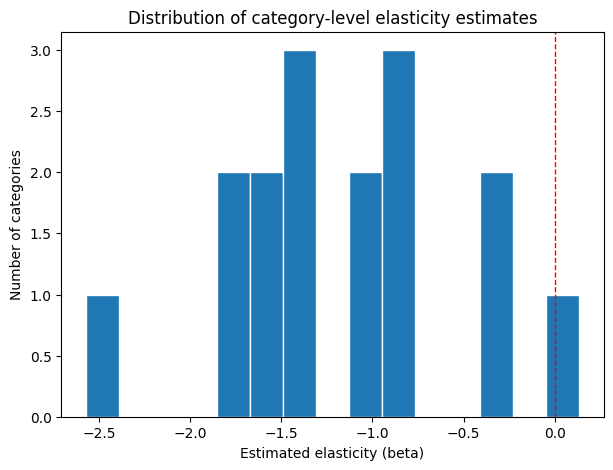

In [19]:
if len(segment_df) > 0:
    plt.figure(figsize=(7, 5))
    plt.hist(segment_df["elasticity"], bins=15, edgecolor="white")
    plt.axvline(0, color="red", linestyle="--", linewidth=1)
    plt.title("Distribution of category-level elasticity estimates")
    plt.xlabel("Estimated elasticity (beta)")
    plt.ylabel("Number of categories")
    plt.show()

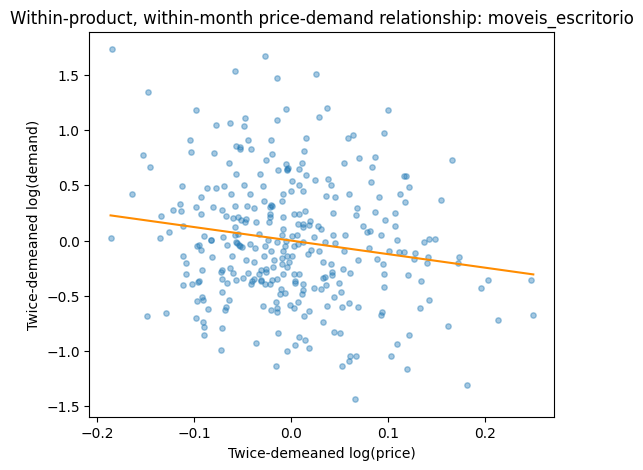

In [20]:
if len(reliable) > 0:
    example_category = reliable.iloc[0]["category"]
    example_data = fe_data[fe_data["product_category_name"] == example_category].copy()

    # Two-way demeaning here is for VISUALIZATION only (illustrating the
    # within-product, within-month relationship the model above actually
    # estimates via absorption) -- it is not used for any reported inference.
    example_data["log_price_demeaned"] = (
        example_data["log_price"]
        - example_data.groupby("product_id")["log_price"].transform("mean")
        - example_data.groupby("period")["log_price"].transform("mean")
        + example_data["log_price"].mean()
    )
    example_data["log_demand_demeaned"] = (
        example_data["log_demand"]
        - example_data.groupby("product_id")["log_demand"].transform("mean")
        - example_data.groupby("period")["log_demand"].transform("mean")
        + example_data["log_demand"].mean()
    )

    plt.figure(figsize=(6, 5))
    plt.scatter(example_data["log_price_demeaned"], example_data["log_demand_demeaned"], alpha=0.4, s=15)
    z = np.polyfit(example_data["log_price_demeaned"], example_data["log_demand_demeaned"], 1)
    xs = np.linspace(example_data["log_price_demeaned"].min(), example_data["log_price_demeaned"].max(), 50)
    plt.plot(xs, np.polyval(z, xs), color="darkorange")
    plt.title(f"Within-product, within-month price-demand relationship: {example_category}")
    plt.xlabel("Twice-demeaned log(price)")
    plt.ylabel("Twice-demeaned log(demand)")
    plt.show()

## 10. Outliers and Data Quality

Extreme values are inspected and, where necessary, capped -- not
silently dropped, and not using any information from outside the
period being described. This is a separate outlier pass from notebook
04's: that one capped raw item-level `price`/`freight_value` for the
demand-forecasting feature set; this one operates on the aggregated
`average_price` used specifically for elasticity, since the
aggregation itself already smooths some item-level noise.

In [21]:
def iqr_bounds(series, k=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return max(q1 - k * iqr, 0), q3 + k * iqr

price_lower, price_upper = iqr_bounds(product_period["average_price"])
demand_lower, demand_upper = iqr_bounds(product_period["demand_quantity"])

n_price_outliers = ((product_period["average_price"] < price_lower) | (product_period["average_price"] > price_upper)).sum()
n_demand_outliers = (product_period["demand_quantity"] > demand_upper).sum()

print(f"average_price IQR bounds: [{price_lower:.2f}, {price_upper:.2f}] -- {n_price_outliers} rows outside this range")
print(f"demand_quantity upper IQR bound: {demand_upper:.2f} -- {n_demand_outliers} rows above it")
print()
print("These are documented, not removed -- the regressions above already used log-transformed values, "
      "which substantially reduces the influence of extreme values without discarding real sales.")

average_price IQR bounds: [0.00, 460.30] -- 2567 rows outside this range
demand_quantity upper IQR bound: 5.00 -- 2410 rows above it

These are documented, not removed -- the regressions above already used log-transformed values, which substantially reduces the influence of extreme values without discarding real sales.


## 11. Model Diagnostics

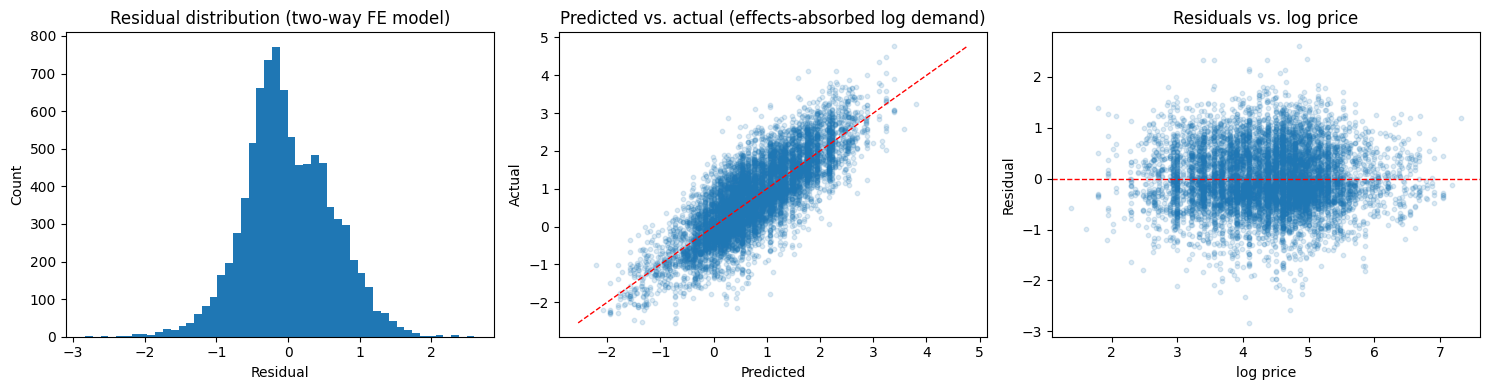

In [22]:
# Align residuals/fitted values back to fe_data via the panel MultiIndex
# rather than assuming row order matches -- PanelOLS can drop or reorder
# observations internally (e.g. singleton groups), so positional
# alignment isn\'t safe.
diag_df = fe_model.fitted_values.join(fe_model.resids)
diag_df = diag_df.join(fe_panel[["log_price"]])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(diag_df["residual"], bins=50)
axes[0].set_title("Residual distribution (two-way FE model)")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Count")

actual = diag_df["fitted_values"] + diag_df["residual"]
axes[1].scatter(diag_df["fitted_values"], actual, alpha=0.15, s=10)
lims = [min(diag_df["fitted_values"].min(), actual.min()), max(diag_df["fitted_values"].max(), actual.max())]
axes[1].plot(lims, lims, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Predicted vs. actual (effects-absorbed log demand)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

axes[2].scatter(diag_df["log_price"], diag_df["residual"], alpha=0.15, s=10)
axes[2].axhline(0, color="red", linestyle="--", linewidth=1)
axes[2].set_title("Residuals vs. log price")
axes[2].set_xlabel("log price")
axes[2].set_ylabel("Residual")

plt.tight_layout()
plt.show()

**Limitations, stated plainly:**

- The low within-R-squared across every model in this notebook means
  price explains a small share of month-to-month demand variation for
  any given product -- most of the variation comes from factors this
  notebook doesn't model (promotions, stock-outs, marketing).
- Every estimate here is **conditional on observed selling months**
  (Section 4) -- there is no zero-sale-month data to extend this to a
  full market-demand panel.
- **Seller-mix** (Section 5b/8b) is a documented, only partially
  resolved limitation: `average_price` blends across sellers for
  multi-seller products, and the product-seller robustness check helps
  but doesn't fully rule this out.
- Nothing in this notebook supports a **causal** claim -- only an
  observational, associational one. A product's price and its demand
  can move together for reasons other than price *causing* the demand
  change (e.g. a seller cutting price specifically during a slow month,
  which would bias the coefficient in either direction depending on
  why), and two-way fixed effects control for product- and
  time-level confounders, not all confounders.

## 12. Business Interpretation

**Filled in from the actual numbers computed above, not assumed:**

1. **Is overall demand elastic or inelastic?** Read the sign and
   magnitude of `fe_beta` from Section 8 -- if it's below -1, demand is
   elastic; between -1 and 0, inelastic; near 0, price-insensitive at
   this level of aggregation. This describes demand **conditional on a
   sale occurring** (Section 4's limitation), not the full market.
2. **Most price-sensitive categories:** the `reliable` table's most
   negative rows in Section 9 (statistically detectable, `beta < 0`).
3. **Least price-sensitive categories, among those with a genuine
   negative, detectable relationship:** the `reliable` table's rows
   closest to zero. Categories with **no statistically detectable
   elasticity** (`not_detected`) aren't "insensitive" -- there simply
   isn't enough signal to say either way. Categories with a
   **statistically detectable positive coefficient**
   (`positive_detected`) are flagged separately and are **not**
   reported as low price sensitivity -- a positive coefficient
   contradicts standard downward-sloping demand and more likely
   reflects confounding than genuine insensitivity (Section 9's
   caveat).
4. **Pricing strategy implication:** categories with elasticity closer
   to 0 or in the inelastic range (`-1 < beta < 0`) are where a price
   increase is less likely to sharply reduce volume -- worth testing
   carefully, not assuming, since this is associational. Categories
   with elasticity below -1 are exactly where price increases risk
   losing enough volume to hurt revenue even though each unit sells for
   more.
5. **Where a price increase could increase revenue:** inelastic
   segments, in principle -- revenue = price * quantity, and if
   quantity falls proportionally less than price rises, revenue rises.
   This is a directional read from the elasticity sign, not a
   recommendation -- Phase 7 is where an actual price change gets
   evaluated against this trade-off explicitly.
6. **Where a price increase could hurt revenue:** elastic segments
   (`beta < -1`), where the proportional drop in quantity outweighs the
   proportional price gain.

No specific optimal price is recommended in this notebook -- these
elasticity estimates are Phase 7's input, not its output.

## 13. Prepare for Price Optimization

A clean elasticity table for Phase 7, combining category-level segment
estimates with the overall within-product estimate as a fallback.

**Reliability flag -- revised to combine three things, not p-value
alone:**

1. **Sign consistency:** a positive coefficient is flagged
   `positive_likely_confounded` regardless of its p-value -- per
   Section 9's caveat, it's never treated as a usable negative
   elasticity.
2. **Statistical detectability:** `p_value >= 0.05` is flagged
   `not_detected` -- not "zero effect", just "not enough signal here."
3. **Precision, not just sample size:** among detectable negative
   estimates, `reliable` additionally requires a reasonably tight 95%
   CI (width < 2.0 log-points) on top of `n_obs >= 500` -- a large
   sample with a still-wide interval (seen in a few categories above)
   is downgraded to `moderate` rather than called reliable just because
   `n_obs` cleared a bar.

In [23]:
elasticity_results = segment_df.copy()
elasticity_results["model"] = "within_product_category_segment_two_way_fe"

def classify_reliability(row):
    if row["elasticity"] >= 0:
        return "positive_likely_confounded"
    if row["p_value"] >= 0.05:
        return "not_detected"
    ci_width = row["ci_high"] - row["ci_low"]
    if row["n_obs"] >= 500 and ci_width < 2.0:
        return "reliable"
    if row["n_obs"] >= 200:
        return "moderate"
    return "low_confidence"

elasticity_results["reliability_flag"] = elasticity_results.apply(classify_reliability, axis=1)

average_price_by_cat = filtered_period.groupby("product_category_name")["average_price"].mean()
average_demand_by_cat = filtered_period.groupby("product_category_name")["demand_quantity"].mean()
elasticity_results["average_price"] = elasticity_results["category"].map(average_price_by_cat)
elasticity_results["average_demand"] = elasticity_results["category"].map(average_demand_by_cat)

overall_fallback = pd.DataFrame([{
    "category": "__OVERALL_WITHIN_PRODUCT__",
    "n_obs": fe_n,
    "n_products": n_products_fe,
    "elasticity": fe_beta,
    "clustered_se": fe_se,
    "p_value": fe_p,
    "r2_within": fe_r2_within,
    "ci_low": fe_ci[0],
    "ci_high": fe_ci[1],
    "model": "within_product_overall_two_way_fe",
    "average_price": filtered_period["average_price"].mean(),
    "average_demand": filtered_period["demand_quantity"].mean(),
}])
overall_fallback["reliability_flag"] = overall_fallback.apply(classify_reliability, axis=1)

elasticity_results = pd.concat([elasticity_results, overall_fallback], ignore_index=True)
elasticity_results = elasticity_results[[
    "category", "elasticity", "clustered_se", "p_value", "ci_low", "ci_high",
    "n_obs", "n_products", "r2_within", "average_price", "average_demand",
    "model", "reliability_flag",
]]

assert len(elasticity_results) > 0, "elasticity_results is empty -- nothing to hand off to Phase 7."
print(elasticity_results["reliability_flag"].value_counts())
elasticity_results

reliability_flag
moderate                      7
reliable                      5
not_detected                  4
positive_likely_confounded    1
Name: count, dtype: int64


,category,elasticity,clustered_se,p_value,ci_low,ci_high,n_obs,n_products,r2_within,average_price,average_demand,model,reliability_flag
0,moveis_escritorio,-2.571053,1.054915,1.545428e-02,-4.648064,-0.494043,323,35,0.075457,151.142333,2.733746,within_product_category_segment_two_way_fe,moderate
1,relogios_presentes,-1.767376,0.253861,1.268408e-11,-2.266345,-1.268406,507,60,0.148179,201.377254,4.429980,within_product_category_segment_two_way_fe,reliable
2,cama_mesa_banho,-1.742481,0.387842,7.958778e-06,-2.503674,-0.981288,1031,122,0.036008,98.488311,3.218235,within_product_category_segment_two_way_fe,reliable
3,perfumaria,-1.611820,0.942837,8.884885e-02,-3.470614,0.246973,258,30,0.011965,120.286438,3.875969,within_product_category_segment_two_way_fe,not_detected
4,moveis_decoracao,-1.530650,0.773506,4.850036e-02,-3.051171,-0.010128,490,58,0.038901,95.300257,4.295918,within_product_category_segment_two_way_fe,moderate
5,brinquedos,-1.473332,0.504523,3.778920e-03,-2.466426,-0.480239,345,41,0.037754,97.693798,3.089855,within_product_category_segment_two_way_fe,moderate
6,cool_stuff,-1.360657,0.558224,1.519090e-02,-2.457816,-0.263498,513,59,0.023584,141.159618,3.639376,within_product_category_segment_two_way_fe,moderate
7,ferramentas_jardim,-1.350516,0.734712,6.727010e-02,-2.797794,0.096761,287,26,0.017066,88.590290,9.620209,within_product_category_segment_two_way_fe,not_detected
8,eletronicos,-1.038893,0.492799,3.596802e-02,-2.009244,-0.068542,320,38,-0.003571,45.397944,2.931250,within_product_category_segment_two_way_fe,moderate
9,informatica_acessorios,-1.035975,0.275913,1.922624e-04,-1.577962,-0.493988,645,81,0.034377,93.065322,4.190698,within_product_category_segment_two_way_fe,reliable


## 14. Save Results

In [24]:
RESULTS_PATH = PROCESSED_DIR / "price_elasticity_results.csv"
elasticity_results.to_csv(RESULTS_PATH, index=False)

MODEL_PATH = MODEL_DIR / "price_elasticity_model.pkl"
joblib.dump({
    "baseline_model": baseline_model,
    "within_product_model": fe_model,
    "min_periods_threshold": MIN_PERIODS,
    "min_category_obs_threshold": MIN_CATEGORY_OBS,
}, MODEL_PATH)

assert RESULTS_PATH.exists(), "price_elasticity_results.csv was not written."
assert MODEL_PATH.exists(), "price_elasticity_model.pkl was not written."
print("Saved:", RESULTS_PATH)
print("Saved:", MODEL_PATH)

Saved: d:\pricing-optimization-system\data\processed\price_elasticity_results.csv
Saved: d:\pricing-optimization-system\models\price_elasticity_model.pkl


## 15. Final Validation

In [26]:
assert len(master_df) > 0, "master_df is empty."
assert (baseline_data["average_price"] > 0).all(), "Non-positive price found in baseline data."
assert (baseline_data["demand_quantity"] > 0).all(), "Non-positive demand found in baseline data."
assert product_period.duplicated(subset=["product_id", "period"]).sum() == 0, "Duplicate product-period rows."
assert len(elasticity_results) > 0, "elasticity_results is empty."
assert RESULTS_PATH.exists()
assert MODEL_PATH.exists()

print("All validation checks passed.")


All validation checks passed.
